<b><font size="10" color="#E8800A">Notebook 1 · Data Exploration </font></b><br>
<b><font size="6">Importação e análise inicial dos dados em bruto</font></b><br>

**Objetivo.** Observar e diagnosticar os dados em bruto (`train.csv`, `test.csv` e `clientes.csv`): estrutura, qualidade, distribuições, relação com o target `repeat_purchase_90d`, estrutura temporal e ligação ao `clientes.csv`.

**O que este notebook não faz.** Não altera, limpa nem transforma os dados. A limpeza, a integração do `clientes.csv`, o encoding e a engenharia de features ficam para o `notebook_02_preprocessing`.

**Output.** Uma lista de problemas detetados (secção 10), cada um com a evidência que o sustenta.

**Regra anti-fuga de informação.** O `test.csv` é usado apenas para comparar distribuições com o treino. Nada dele é usado para ajustar transformações, e `train` e `test` são mantidos em variáveis separadas ao longo de todo o notebook.

<div class="alert alert-block alert-info">

# TOC<a class="anchor" id="toc"></a>

* [<font color='#E8800A'>1 - Setup e Carregamento</font>](#sc)
* [<font color='#E8800A'>2 - Visão geral e dicionário de dados</font>](#visao)
* [<font color='#E8800A'>3 - Qualidade dos dados</font>](#qualidade)
* [<font color='#E8800A'>4 - Target e desequilíbrio de classes</font>](#target)
* [<font color='#E8800A'>5 - Estatísticas descritivas e distribuições</font>](#estatistica)
* [<font color='#E8800A'>6 - Relações com o target</font>](#relacao)
* [<font color='#E8800A'>7 - Estrutura temporal, repetição de clientes e deriva train vs. test</font>](#temporal)
* [<font color='#E8800A'>8 - Análise crítica de identificadores e ruído</font>](#analise)
* [<font color='#E8800A'>9 - Ligação com o clientes.csv</font>](#clientes)
* [<font color='#E8800A'>10 - Conclusões e lista de decisões para o notebook 02</font>](#conclusao)

</div>

# <font color='#E8800A'>1 - Setup e Carregamento</font><a class="anchor" id="sc"></a>

[Back to TOC](#toc)

<b><font size="6">Dicionario de dados:
</font></b><br>
**O que há no ficheiro.** Cada linha corresponde a uma compra: `ID` identifica a linha e é tratado como identificador (fora das features), ficando 38 colunas além do alvo e dos identificadores. O alvo é **`repeat_purchase_90d`**: 1 se o cliente voltaria a comprar nos 90 dias seguintes, 0 se não. Existe apenas no treino.

| coluna | o que contém | papel |
|---|---|---|
| `repeat_purchase_90d` | 1 = voltou a comprar em 90 dias, 0 = não | **alvo** |
| `ID` | um valor por linha/submissão | identificador, nunca uma feature |
| `customer_id` | um valor por cliente (um cliente pode aparecer mais do que uma vez); chave de ligação ao `clientes.csv` | identificador, nunca uma feature |
| `purchase_date` | data da compra, anonimizada (ordem e intervalos preservados) | data |
| `payment_type` | forma de pagamento | categórica |
| `salesperson` | vendedor | categórica |
| `commercial_zone` | zona comercial | categórica |
| `transport_method` | método de transporte | categórica |
| `warehouse` | armazém | categórica |
| `document_series` | série documental | categórica |
| `Total a Pagar` | valor total a pagar da compra atual | numérica, monetária |
| `Total Bruto` | total bruto da compra atual | numérica, monetária |
| `Total Liquido` | total líquido da compra atual | numérica, monetária |
| `Total Imp_` | total de impostos | numérica, monetária |
| `Total Portes` | total de portes | numérica, monetária |
| `Total Desc_ Global` | desconto global | numérica, monetária |
| `Total Desc_ Linha` | descontos ao nível da linha | numérica, monetária |
| `Custo` | custo da compra atual | numérica, monetária |
| `N_ Detalhes` | nº de linhas de detalhe da compra | contagem |
| `invoice_count_current_purchase` | nº de faturas da compra | contagem |
| `days_since_previous_purchase` | dias desde a compra anterior | numérica, recência |
| `customer_tenure_days` | antiguidade do cliente, em dias | numérica, recência |
| `prior_purchase_count` | nº de compras anteriores | contagem, histórico |
| `prior_mean_gap_days` | média dos intervalos entre compras anteriores | numérica, histórico |
| `prior_std_gap_days` | desvio-padrão dos intervalos entre compras anteriores | numérica, histórico |
| `prior_total_spend` | gasto total anterior | numérica, histórico de valor |
| `prior_mean_purchase_value` | valor médio das compras anteriores | numérica, histórico de valor |
| `prior_std_purchase_value` | desvio-padrão do valor das compras anteriores | numérica, histórico de valor |
| `prior_min_purchase_value` | valor mínimo das compras anteriores | numérica, histórico de valor |
| `prior_max_purchase_value` | valor máximo das compras anteriores | numérica, histórico de valor |
| `purchase_count_30d` / `_90d` / `_180d` / `_365d` | nº de compras nos 30, 90, 180 e 365 dias anteriores | contagem, janela rolling |
| `spend_30d` / `_90d` / `_180d` / `_365d` | gasto nos 30, 90, 180 e 365 dias anteriores | numérica, janela rolling |
| `random_noise` | campo numérico adicional | **a avaliar**: pode não ter informação útil |

**As colunas agrupam-se em blocos com leituras diferentes.** As oito colunas monetárias descrevem apenas a compra atual e são fortemente relacionadas entre si (bruto, líquido, impostos e total a pagar derivam uns dos outros), pelo que convém verificar a colinearidade. As colunas `prior_*` e as janelas rolling descrevem só o que aconteceu *antes* da compra, e é isso que as torna utilizáveis como features sem fuga de informação. As janelas são encaixadas (a de 365 dias contém a de 30), portanto também são correlacionadas.

**`purchase_date` não é uma feature pronta a usar.** Como a data foi anonimizada mas a ordem e os intervalos foram preservados, serve para ordenar e partir os dados no tempo, ou para derivar features de calendário relativas. O valor absoluto não tem significado.

**`random_noise` serve de referência.** Se uma feature real não tiver mais importância do que ela, provavelmente não acrescenta nada.

Importação das bibliotecas necessárias para o desenvolvimento e análise dos dados neste NB, nomeadamente o pandas

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
from scipy.stats import chi2_contingency
from scipy.stats.contingency import association

sns.set_theme(style="whitegrid")
PLOT_BLUE, PLOT_ORANGE = "#1779A8", "#E8800A"

Leitura dos ficheiros clientes.csv, train.csv, test.csv e sample_submission.csv, que serão utilizados ao longo do projeto.

In [4]:
clientes_data = pd.read_csv("../data/Raw/clientes.csv")

sample_sub = pd.read_csv("../data/Raw/sample_submission.csv")

test_data = pd.read_csv("../data/Raw/test.csv")

train_data = pd.read_csv("../data/Raw/train.csv")

In [5]:
print(f"{train_data.shape[0]:,} rows x {train_data.shape[1]} columns")
train_data.head(3)

6,534 rows x 39 columns


,Total a Pagar,Total Bruto,Total Liquido,Total Imp_,Total Portes,Total Desc_ Global,Total Desc_ Linha,Custo,N_ Detalhes,invoice_count_current_purchase,...,customer_id,payment_type,salesperson,commercial_zone,transport_method,warehouse,document_series,purchase_date,ID,random_noise
0,558.11,510.90,453.75,104.36,0.0,0.0,57.15,153.099911,4.0,1.0,...,660784,Maybe Tomorrow Payment 10,VLOOKUP Master 9,Decorative Dashboard Zone 4,Maybe Tomorrow Delivery 61,Final Excel Warehouse 1,Ctrl Z Series 2,2024-10-29,10000000,-0.660448
1,978.80,830.02,795.77,183.03,0.0,0.0,34.25,472.943134,32.0,1.0,...,189146,Maybe Tomorrow Payment 7,VLOOKUP Master 1,Decorative Dashboard Zone 4,Maybe Tomorrow Delivery 36,Final Excel Warehouse 1,Ctrl Z Series 1,2017-07-08,10000001,0.924510
2,10.33,12.00,8.40,1.93,0.0,0.0,3.60,6.097485,1.0,1.0,...,103940,Maybe Tomorrow Payment 9,VLOOKUP Master 1,Decorative Dashboard Zone 4,NaN,Final Excel Warehouse 1,Ctrl Z Series 3,2019-03-19,10000002,-0.258730


# <font color='#E8800A'>2 - Visão geral e dicionário de dados</font><a class="anchor" id="visao"></a>

[Back to TOC](#toc)

Antes de olhar para valores, confirma-se que os quatro ficheiros são coerentes entre si: mesmas colunas, mesmos tipos, e um `sample_submission` que aponta para as linhas do `test.csv`. Um desalinhamento aqui contaminaria tudo o que vem depois.

In [6]:
files = {"train": train_data, 
         "test": test_data,
         "clientes": clientes_data, 
         "sample_submission": sample_sub
       }

print(pd.DataFrame({name: {"rows": f.shape[0], 
                           "columns": f.shape[1]
                           }
                    for name, f in files.items()}).T.to_string())

#verificação de diferenças entre elementos de train e test
only_train = sorted(set(train_data.columns) - set(test_data.columns))
only_test = sorted(set(test_data.columns) - set(train_data.columns))
print("\ncolumns only in train:", only_train)
print("columns only in test: ", only_test)

#verificação de diferenças de tipos entre elementos de train e test
shared = [c for c in train_data.columns if c in test_data.columns]
dtype_mismatch = {c: (str(train_data[c].dtype), str(test_data[c].dtype))
                  for c in shared if train_data[c].dtype != test_data[c].dtype}
print("dtype mismatches train vs test:", dtype_mismatch or "none")

submission_id = sample_sub.columns[0]

print("\nsample_submission columns:", list(sample_sub.columns))
print("sample_submission ids == test ids:",
      set(sample_sub[submission_id]) == set(test_data["ID"]))
print("ids shared between train and test:",
      len(set(train_data["ID"]) & set(test_data["ID"])))

                   rows  columns
train              6534       39
test                986       38
clientes           1143       13
sample_submission   986        2

columns only in train: ['repeat_purchase_90d']
columns only in test:  []
dtype mismatches train vs test: {'N_ Detalhes': ('float64', 'int64'), 'invoice_count_current_purchase': ('float64', 'int64'), 'customer_tenure_days': ('float64', 'int64'), 'prior_purchase_count': ('float64', 'int64'), 'purchase_count_30d': ('float64', 'int64'), 'purchase_count_90d': ('float64', 'int64'), 'purchase_count_180d': ('float64', 'int64'), 'purchase_count_365d': ('float64', 'int64')}

sample_submission columns: ['ID', 'repeat_purchase_90d']
sample_submission ids == test ids: True
ids shared between train and test: 0


O único elemento esperado só no treino é `repeat_purchase_90d`. Qualquer outra diferença de colunas ou de tipo teria de ser resolvida no NB02 antes de aplicar a mesma transformação aos dois ficheiros. Ids partilhados entre treino e teste indicariam sobreposição de linhas, o que seria uma fuga direta (data leakage).

In [7]:
#separamos as categorias
identifiers = ["ID", "customer_id"]
target = "repeat_purchase_90d"
numeric = [c for c in train_data.columns
           if c not in identifiers + [target]
           and pd.api.types.is_numeric_dtype(train_data[c])]
categorical = [c for c in train_data.columns
               if c not in identifiers + [target] + numeric]

# Procura colunas guardadas como uma variavel mas que na verdade são outras.
# 
low_cardinality = {c: train_data[c].nunique() for c in numeric if train_data[c].nunique() <= 10}
levels = train_data[categorical].nunique().sort_values(ascending=False)
for column in levels[levels <= 10].index:
    print(f"Needs encoding: {column:20s} {sorted(train_data[column].dropna().unique())}")

roles = pd.Series({
    "identifiers": f"{len(identifiers)} {identifiers}",
    "numeric": f"{len(numeric)}, of which low-cardinality: {low_cardinality}",
    "categorical": f"{len(categorical)}, holding {int(levels.sum())} levels"
                   f" -> {int(levels.sum())} columns once encoded",
    "target": target,
})
print(roles.to_frame("what each group holds").to_string())
levels.to_frame("levels")

Needs encoding: payment_type         ['Maybe Tomorrow Payment 10', 'Maybe Tomorrow Payment 11', 'Maybe Tomorrow Payment 12', 'Maybe Tomorrow Payment 2', 'Maybe Tomorrow Payment 3', 'Maybe Tomorrow Payment 4', 'Maybe Tomorrow Payment 7', 'Maybe Tomorrow Payment 8', 'Maybe Tomorrow Payment 9']
Needs encoding: salesperson          ['VLOOKUP Master 1', 'VLOOKUP Master 2', 'VLOOKUP Master 3', 'VLOOKUP Master 4', 'VLOOKUP Master 5', 'VLOOKUP Master 6', 'VLOOKUP Master 7', 'VLOOKUP Master 8', 'VLOOKUP Master 9']
Needs encoding: commercial_zone      ['Decorative Dashboard Zone 2', 'Decorative Dashboard Zone 3', 'Decorative Dashboard Zone 4', 'Decorative Dashboard Zone 6', 'Decorative Dashboard Zone 7']
Needs encoding: document_series      ['Ctrl Z Series 1', 'Ctrl Z Series 2', 'Ctrl Z Series 3']
Needs encoding: warehouse            ['Final Excel Warehouse 1', 'Final Excel Warehouse 3']
                                                           what each group holds
identifiers                 

,levels
purchase_date,1492
transport_method,80
payment_type,9
salesperson,9
commercial_zone,5
document_series,3
warehouse,2


`purchase_date` (1492 níveis). Está guardada como texto, por isso a triagem classificou-a como categórica e é ela que explica quase todas as 1600 colunas previstas após one-hot (as outras seis categóricas somam cerca de 108 níveis). Na fase de limpeza, deve ser convertida para datetime e deixada fora das features, porque codificar cada data como categoria não generaliza (as datas do teste são futuras e nunca vistas) e o valor absoluto não tem significado, já que foi anonimizado. A coluna continua útil para ordenar os dados e fazer o corte temporal treino/validação, com uma margem de 90 dias por causa da janela do alvo. Nesta fase nada é alterado: é só diagnóstico.

**Listagem dos valores (limite de 10 níveis).** O limite de 10 valores (<= 10) serve para identificar variáveis que têm poucos valores distintos dentro da nossa opinião e que, por isso, podem precisar de encoding.

**Encoding.** Todas as categóricas, exceto `purchase_date`, precisam de encoding. As cinco com 10 níveis ou menos podem ir para one-hot sem problemas; 
`transport_method` (80 níveis) pode exigir agrupar os níveis raros em "Outros".

# <font color='#E8800A'>3 - Qualidade dos dados</font><a class="anchor" id="qualidade"></a>

[Back to TOC](#toc)

Esta secção procura o que está **errado**, não o que está distribuído de forma estranha: duplicados, vazios (e se se explicam pela estrutura dos dados), valores impossíveis, valores sentinela (flag) e relações lógicas entre colunas que têm de se verificar. Nada é alterado em `train_data`; os achados alimentam a lista de decisões da secção 10.

**Convenções usadas daqui em diante.** `purchase_date` é uma data e não uma categoria, por isso fica fora de `categorical_features`. `SENTINEL_FLOOR` marca o limiar a partir do qual um valor deixa de poder ser um valor real neste ficheiro.

In [8]:
date_col = "purchase_date"
categorical_features = [c for c in categorical if c != date_col]
SENTINEL_FLOOR = 1e8   # no real purchase value in this file comes anywhere near this

In [9]:
duplicate_rows = train_data.duplicated().sum()
print("duplicates ignoring the index:", duplicate_rows)

per_customer = train_data.groupby("customer_id").size()
print(f"\ntotal distinct customers: {train_data['customer_id'].nunique()}")
print(f"surplus rows on 'customer_id': {train_data.duplicated(subset='customer_id').sum()}")
print(f"rows sharing an 'customer_id': {per_customer[per_customer > 1].sum()}"
      f" across {(per_customer > 1).sum()} customers")
print("records per customer:", per_customer.value_counts().to_dict())

duplicates ignoring the index: 0

total distinct customers: 610
surplus rows on 'customer_id': 5924
rows sharing an 'customer_id': 6377 across 453 customers
records per customer: {1: 157, 2: 84, 3: 49, 4: 47, 6: 25, 5: 23, 7: 21, 10: 14, 15: 13, 9: 13, 11: 12, 8: 11, 13: 10, 21: 9, 14: 8, 18: 8, 24: 7, 17: 7, 16: 6, 29: 5, 26: 5, 22: 4, 12: 4, 50: 4, 19: 4, 35: 3, 31: 3, 23: 3, 30: 3, 28: 3, 89: 2, 42: 2, 54: 2, 41: 2, 63: 2, 51: 2, 32: 2, 37: 2, 27: 2, 36: 2, 277: 1, 43: 1, 38: 1, 25: 1, 74: 1, 81: 1, 203: 1, 33: 1, 49: 1, 59: 1, 39: 1, 67: 1, 73: 1, 48: 1, 53: 1, 66: 1, 62: 1, 55: 1, 80: 1, 112: 1, 60: 1, 47: 1, 40: 1, 56: 1, 20: 1}


**Duplicados e `customer_id`.** Não há linhas duplicadas, por isso não há limpeza a fazer nesse sentido. O `customer_id` não identifica linhas: as 6534 compras pertencem a 610 clientes distintos, dos quais 453 têm +1 compra e 157 têm 1. 
A distribuição é muito enviesada (skewed): a maioria tem poucas compras, mas existem clientes com 277, 203 e 112, que pesam bastante no dataset. Assumindo que os clientes do teste aparecem quase todos no treino, o histórico por cliente é informação legítima e a validação deve ser feita por **corte temporal**. O `customer_id` fica fora das features, para o modelo não decorar clientes.

In [10]:
rows_with_null = train_data.isna().any(axis=1)
per_column = train_data.isna().sum()

pd.Series({
    "rows with a null": f"{rows_with_null.sum():,} of {len(train_data):,}"
                        f" ({100 * rows_with_null.mean():.2f}%)",
    "columns with a null": f"{(per_column > 0).sum()} of {train_data.shape[1]}",
    "null cells": f"{train_data.isna().sum().sum():,}",
    "worst column": f"{per_column.idxmax()} ({per_column.max()} nulls)",
}).to_frame("missing values as the file arrives")

,missing values as the file arrives
rows with a null,"2,605 of 6,534 (39.87%)"
columns with a null,36 of 39
null cells,"9,818"
worst column,prior_std_gap_days (1478 nulls)


**2,605 rows of 6,534 (39.87%) contem null, que estao distribuidos em 36 das 39 colunas:** 9,818 celulas no total, mas nenhuma acaba por ser pior que o prior_std_gap_days com 1478 nulls,

Esta é a questão central de qual eixo cortar: Eliminar todas as linhas incompletas custa 39,87% dos dados (2.605 de 6.534 linhas). Eliminar todas as colunas que contêm algum null custa 36 das 39 colunas, sobrando apenas 3. Os valores em falta estão espalhados por quase todas as colunas em vez de concentrados em poucas: mesmo a pior, prior_std_gap_days, tem 1.478 nulls (22,6% das linhas), pelo que não há atalhos baratos.

### 3.1 Anatomia dos valores em falta

A tabela de estatísticas mostrou 6469 valores em muitas colunas contra 6534 linhas, ou seja, 65 linhas a menos. A primeira pergunta é se esses 65 vazios são as **mesmas linhas** em todas as colunas, e o que têm de comum.

nulls in each purchase-total column:
Total a Pagar    65
Total Bruto      65
Total Liquido    65
Total Imp_       65
Custo            65

rows where ALL of them are null: 65

                rows  mean nulls per row  target rate  distinct customers
totals missing    65              36.000        0.508                  53
totals present  6469               1.156        0.560                 607


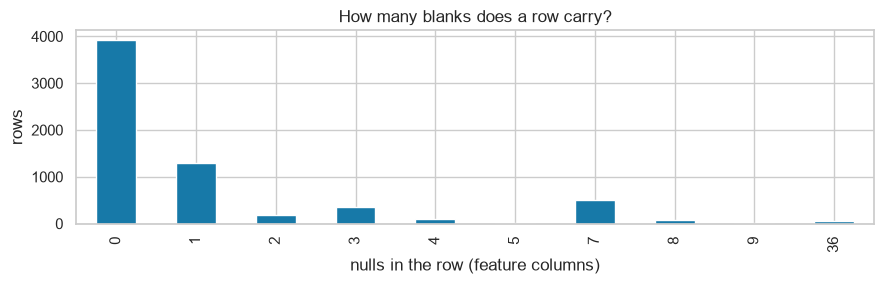

In [11]:
#quantos valores faltam nas colunas $
purchase_totals = ["Total a Pagar", "Total Bruto", "Total Liquido", "Total Imp_", "Custo"]
nulls_per_row = train_data.drop(columns=[target]).isna().sum(axis=1)

print("nulls in each purchase-total column:")
print(train_data[purchase_totals].isna().sum().to_string())
no_totals = train_data[purchase_totals].isna().all(axis=1)
print(f"\nrows where ALL of them are null: {no_totals.sum()}")

profile = pd.DataFrame({
    "rows": [no_totals.sum(), (~no_totals).sum()],
    "mean nulls per row": [nulls_per_row[no_totals].mean(), nulls_per_row[~no_totals].mean()],
    "target rate": [train_data.loc[no_totals, target].mean(),
                    train_data.loc[~no_totals, target].mean()],
    "distinct customers": [train_data.loc[no_totals, "customer_id"].nunique(),
                           train_data.loc[~no_totals, "customer_id"].nunique()],
}, index=["totals missing", "totals present"])
print()
print(profile.round(3).to_string())

fig, ax = plt.subplots(figsize=(9, 3))
nulls_per_row.value_counts().sort_index().plot(kind="bar", color=PLOT_BLUE, ax=ax)
ax.set(xlabel="nulls in the row (feature columns)", ylabel="rows",
       title="How many blanks does a row carry?")
plt.tight_layout()
plt.show()

Cada uma das cinco colunas de totais (`Total a Pagar`, `Total Bruto`, `Total Liquido`, `Total Imp_` e `Custo`) tem exatamente 65 valores em falta. Há também exatamente 65 linhas em que as cinco estão vazias, ou seja, os nulos coincidem sempre nas mesmas linhas: não são falhas isoladas, é um conjunto de 65 linhas sem qualquer valor de compra.

Essas 65 linhas têm em média 36 nulos por linha, contra 1,156 nas restantes 6469. Isto indica que não lhes faltam só os totais: estão praticamente vazias em quase todas as colunas.

Quanto à tabela:
- **Tamanho:** o grupo sem totais é pequeno, cerca de 1% do train (65 de 6534).
- **Nulos por linha:** nestas colunas há em media 36 nulos por linha (tendo no total 39 colunas) enquanto que nas outras colunas, 1,1.
- **Taxa do target:** 0,508 contra 0,560, uma diferença pequena. Com apenas 65 linhas, essa diferença está dentro do que se esperaria por acaso.
- **Clientes distintos:** as 65 linhas envolvem 53 clientes, ou seja, quase um cliente por linha, enquanto as restantes 6469 linhas envolvem 607 clientes.

Muitos vazios nas colunas `prior_*` são **estruturais**: o desvio-padrão dos intervalos precisa de pelo menos três compras, a média do valor precisa de pelo menos uma. Um vazio explicado pela estrutura não é um defeito. Um vazio que a estrutura não explica é. O código testa essas regras como **hipóteses** (a contagem pode incluir ou não a compra atual) e mostra onde falham.

In [12]:
n_prior = train_data["prior_purchase_count"]
structural_rules = {
    "days_since_previous_purchase": n_prior == 0,
    "prior_mean_purchase_value": n_prior == 0,
    "prior_min_purchase_value": n_prior == 0,
    "prior_max_purchase_value": n_prior == 0,
    "prior_std_purchase_value": n_prior <= 1,
    "prior_mean_gap_days": n_prior <= 1,
    "prior_std_gap_days": n_prior <= 2,
}
rows = []
for column, rule in structural_rules.items():
    is_null = train_data[column].isna()
    rows.append({
        "column": column,
        "nulls": int(is_null.sum()),
        "explained by history": int((is_null & rule).sum()),
        "unexplained": int((is_null & ~rule).sum()),
        "unexplained outside the no-totals rows": int((is_null & ~rule & ~no_totals).sum()),
        "rule true but value present": int((~is_null & rule).sum()),
    })
structure = pd.DataFrame(rows).set_index("column")
print(structure.to_string())

other_nulls = train_data.drop(columns=[target]).isna().sum()
other_nulls = other_nulls[(other_nulls > 0) & ~other_nulls.index.isin(structural_rules)]
print("\nnulls in the remaining columns (no structural rule):")
print(other_nulls.sort_values(ascending=False).to_string())

                              nulls  explained by history  unexplained  unexplained outside the no-totals rows  rule true but value present
column                                                                                                                                     
days_since_previous_purchase    861                   603          258                                     193                            0
prior_mean_purchase_value       862                   603          259                                     194                            0
prior_min_purchase_value        668                   603           65                                       0                            0
prior_max_purchase_value        668                   603           65                                       0                            0
prior_std_purchase_value       1113                  1048           65                                       0                            0
prior_mean_gap_days 

A coluna *unexplained outside the no-totals rows* é a que importa: o que sobra aí é perda de dados genuína (e não ausência de histórico). Se *rule true but value present* for grande, a regra estava mal formulada (por exemplo, a contagem já inclui a compra atual) e ajusta-se o limiar antes de tirar conclusões.

Verifica-se se os valores em falta nas colunas de histórico do cliente são estruturais, isto é, se resultam de o cliente ainda não ter compras anteriores suficientes para a estatística existir. Para cada coluna define-se uma regra: sem compras anteriores (`prior_purchase_count == 0`) não há compra anterior, média, mínimo nem máximo; com no máximo uma, não há desvio padrão dos valores nem intervalo médio entre compras; com no máximo duas, não há desvio padrão dos intervalos.

A tabela `structure` separa, para cada coluna, os nulos explicados pelo histórico dos inexplicados, indica quantos dos inexplicados estão fora das 65 linhas sem totais, e conta os casos em que a regra prevê um nulo mas o valor existe. Por fim, lista os nulos das restantes colunas, que não têm regra estrutural.

**Resultado.** Os vazios das colunas `prior_*` e de `days_since_previous_purchase` têm duas origens. A maioria é estrutural: 603 nas colunas de valor e de recência, até 1413 em `prior_std_gap_days`, e a regra nunca falha (*rule true but value present* é 0 em todas), por isso os limiares estão certos. O resto são as 65 linhas vazias e, em `days_since_previous_purchase`, `prior_mean_purchase_value` e `prior_mean_gap_days`, cerca de 193 a 195 nulos que o histórico não explica. A mesma ordem de grandeza (cerca de 195 depois de tirar as 65 linhas) repete-se em `transport_method`, `warehouse`, `payment_type`, `salesperson` e `spend_365d`, colunas sem regra estrutural. São vazios dispersos e com a mesma dimensão em colunas muito diferentes (cerca de 3% das linhas em cada), o que é compatível com falhas aleatórias e não com um padrão. As restantes colunas só têm nulos nas 65 linhas vazias, e `prior_min`, `prior_max`, `prior_std_purchase_value` e `prior_std_gap_days` não têm nulos fora delas e da estrutura.

### 3.2 Valores sentinela, negativos e intervalos impossíveis

In [13]:
train_hits = (train_data[numeric] >= SENTINEL_FLOOR).sum()
exact = (train_data[numeric] == 1e9).sum()
test_numeric = [c for c in numeric if c in test_data.columns]
test_hits = (test_data[test_numeric] >= SENTINEL_FLOOR).sum()

sentinels = pd.DataFrame({"train >= 1e8": train_hits, "train == 1e9": exact,
                          "test >= 1e8": test_hits}).fillna(0).astype(int)
print(sentinels[(sentinels > 0).any(axis=1)].to_string())

                           train >= 1e8  train == 1e9  test >= 1e8
prior_mean_purchase_value            16            16            2
spend_365d                           15            15            2


Os negativos já foram listados na tabela abaixo (colunas cujo domínio proíbe valores negativos).

In [14]:
non_negative = [c for c in numeric if c != "random_noise"] + [target]

summary = pd.DataFrame({
    "min": train_data[non_negative].min(),
    "negative_rows": (train_data[non_negative] < 0).sum(),
})
print(summary.round(1).to_string())

                                     min  negative_rows
Total a Pagar                        0.9              0
Total Bruto                          0.8              0
Total Liquido                        0.8              0
Total Imp_                           0.0              0
Total Portes                         0.0              0
Total Desc_ Global                   0.0              0
Total Desc_ Linha                    0.0              0
Custo                                0.0              0
N_ Detalhes                          1.0              0
invoice_count_current_purchase       1.0              0
days_since_previous_purchase        -4.0             16
customer_tenure_days                 0.0              0
prior_purchase_count                 0.0              0
prior_total_spend                    0.0              0
prior_mean_purchase_value        -2478.7             16
prior_std_purchase_value             0.0              0
prior_min_purchase_value             0.9        

**Leitura.** Há negativos em quatro colunas: `days_since_previous_purchase` e `prior_mean_gap_days` (16 linhas cada, todas com o valor -4), `prior_mean_purchase_value` (16 linhas) e `spend_365d` (15 linhas). As colunas monetárias da compra atual não têm nenhum. Um intervalo de -4 dias não pode existir por definição. Nos valores monetários, a célula seguinte testa se são notas de crédito ou dano. Os números (16 e 15) coincidem com os dos valores 1e9 da secção 3.2, mas são linhas diferentes: a cópia de análise de 3.5 mascara 32 e 30 células, o dobro. Fica registado que os três defeitos aparecem na mesma escala.

In [15]:
negative_prior_mean = train_data["prior_mean_purchase_value"] < 0
values = train_data.loc[negative_prior_mean, "prior_mean_purchase_value"]
print(f"{negative_prior_mean.sum()} negative rows, {values.nunique()} distinct values"
      f" (a placeholder would repeat one value)")

# prior_mean_purchase_value should equal prior_total_spend / prior_purchase_count.
# That identity says whether a negative or 1e9 is a real value or damage.
reconstructed = train_data["prior_total_spend"] / n_prior.replace(0, np.nan)
close = (train_data["prior_mean_purchase_value"] - reconstructed).abs() <= np.maximum(
    0.05, 0.01 * reconstructed.abs())
print(f"\nidentity holds within 1% on {close[reconstructed.notna() & train_data['prior_mean_purchase_value'].notna()].mean():.2%}"
      " of the rows where both sides exist")
print("reconstructed value is positive on the negative rows:",
      f"{(reconstructed[negative_prior_mean] > 0).mean():.0%}")
sentinel_mean = train_data["prior_mean_purchase_value"] >= SENTINEL_FLOOR
print("reconstructed value on the sentinel rows (median):",
      round(reconstructed[sentinel_mean].median(), 2) if sentinel_mean.any() else "n/a")

for column in ["days_since_previous_purchase", "prior_mean_gap_days"]:
    negative = train_data[column] < 0
    print(f"\n{column}: {negative.sum()} negative rows, values {sorted(train_data.loc[negative, column].unique())}")

16 negative rows, 16 distinct values (a placeholder would repeat one value)

identity holds within 1% on 98.62% of the rows where both sides exist
reconstructed value is positive on the negative rows: 100%
reconstructed value on the sentinel rows (median): 698.57

days_since_previous_purchase: 16 negative rows, values [np.float64(-4.0)]

prior_mean_gap_days: 16 negative rows, values [np.float64(-4.0)]


**Resultado.** A identidade `média = gasto total / nº de compras` verifica-se em 98,62% das linhas onde as duas partes existem. Nas 16 linhas com média negativa, o valor reconstruído é positivo em 100% dos casos, e nas linhas com 1e9 a mediana reconstruída é 698,57, um valor plausível. Logo, os negativos e os 1e9 são **valores corrompidos, e o valor correto é recuperável** a partir de `prior_total_spend` e `prior_purchase_count`. Não são notas de crédito nem códigos. Isto muda a decisão do NB02 de \"pôr a NaN e imputar\" para \"recalcular\". Os intervalos negativos são diferentes: têm um único valor (-4) repetido 16 vezes em cada coluna, o que aponta para um código ou erro sistemático e não para dano aleatório.

### 3.3 Coerência lógica entre colunas

As colunas não são independentes: as janelas rolling estão encaixadas, o mínimo não pode exceder o máximo, e os totais monetários deviam fechar. Cada linha da tabela é uma regra, e o que interessa é **quantas linhas a violam**, entre as linhas onde a regra se pode avaliar.

In [16]:
d = train_data

def check(name, ok, columns):
    valid = d[list(columns)].notna().all(axis=1)
    return {"rule": name, "rows checked": int(valid.sum()),
            "violations": int((~ok[valid]).sum())}

def close(a, b, rel=0.01, absolute=0.05):
    return (a - b).abs() <= np.maximum(absolute, rel * b.abs())

counts = [f"purchase_count_{w}d" for w in (30, 90, 180, 365)]
spends = [f"spend_{w}d" for w in (30, 90, 180, 365)]
nested = lambda cols: (d[cols[0]] <= d[cols[1]]) & (d[cols[1]] <= d[cols[2]]) & (d[cols[2]] <= d[cols[3]])
zero_iff = lambda: pd.concat([(d[s] == 0) == (d[c] == 0) for s, c in zip(spends, counts)], axis=1).all(axis=1)

rules = [
    check("purchase_count 30d <= 90d <= 180d <= 365d", nested(counts), counts),
    check("spend 30d <= 90d <= 180d <= 365d", nested(spends), spends),
    check("spend_Nd == 0 exactly when purchase_count_Nd == 0", zero_iff(), counts + spends),
    check("prior_min <= prior_mean <= prior_max",
          (d.prior_min_purchase_value <= d.prior_mean_purchase_value)
          & (d.prior_mean_purchase_value <= d.prior_max_purchase_value),
          ["prior_min_purchase_value", "prior_mean_purchase_value", "prior_max_purchase_value"]),
    check("prior_purchase_count >= purchase_count_365d",
          d.prior_purchase_count >= d.purchase_count_365d,
          ["prior_purchase_count", "purchase_count_365d"]),
    check("prior_total_spend >= spend_365d", d.prior_total_spend >= d.spend_365d,
          ["prior_total_spend", "spend_365d"]),
    check("customer_tenure_days >= days_since_previous_purchase",
          d.customer_tenure_days >= d.days_since_previous_purchase,
          ["customer_tenure_days", "days_since_previous_purchase"]),
    check("prior_mean ~ prior_total_spend / prior_purchase_count",
          close(d.prior_mean_purchase_value, d.prior_total_spend / d.prior_purchase_count.replace(0, np.nan))
          | (d.prior_purchase_count == 0),
          ["prior_mean_purchase_value", "prior_total_spend", "prior_purchase_count"]),
    check("Total a Pagar ~ Total Liquido + Total Imp_ + Total Portes",
          close(d["Total a Pagar"], d["Total Liquido"] + d["Total Imp_"] + d["Total Portes"]),
          ["Total a Pagar", "Total Liquido", "Total Imp_", "Total Portes"]),
    check("Total Liquido ~ Total Bruto - Total Desc_ Linha - Total Desc_ Global",
          close(d["Total Liquido"], d["Total Bruto"] - d["Total Desc_ Linha"] - d["Total Desc_ Global"]),
          ["Total Liquido", "Total Bruto", "Total Desc_ Linha", "Total Desc_ Global"]),
    check("Custo <= Total Liquido", d.Custo <= d["Total Liquido"], ["Custo", "Total Liquido"]),
]
consistency = pd.DataFrame(rules).set_index("rule")
consistency["% violated"] = (100 * consistency["violations"] / consistency["rows checked"]).round(2)
print(consistency.sort_values("% violated", ascending=False).to_string())

                                                                      rows checked  violations  % violated
rule                                                                                                      
Total a Pagar ~ Total Liquido + Total Imp_ + Total Portes                     6469         777       12.01
prior_min <= prior_mean <= prior_max                                          5672         220        3.88
prior_total_spend >= spend_365d                                               6274         224        3.57
prior_mean ~ prior_total_spend / prior_purchase_count                         5672          78        1.38
Custo <= Total Liquido                                                        6469          39        0.60
spend 30d <= 90d <= 180d <= 365d                                              6274          15        0.24
spend_Nd == 0 exactly when purchase_count_Nd == 0                             6274           1        0.02
purchase_count 30d <= 90d <= 180d <= 

**Resultado.** Há três grupos. **(1) Regras que se cumprem sempre:** as janelas de contagem encaixadas, `prior_purchase_count >= purchase_count_365d`, `customer_tenure_days >= days_since_previous_purchase` e `Total Liquido = Total Bruto - Total Desc_ Linha - Total Desc_ Global`, com 0 violações em 6469 linhas, uma relação exata. **(2) Violações pequenas:** janelas de gasto encaixadas (15 linhas, o mesmo número dos 1e9 em `spend_365d`), `prior_total_spend >= spend_365d` (224 linhas, 3,57%), `prior_min <= prior_mean <= prior_max` (220 linhas, 3,88%), identidade da média (78 linhas, 1,38%) e `Custo > Total Liquido` (39 linhas, 0,60%). Os 32 valores corrompidos da média só explicam uma parte das 220 e das 78 linhas, e o resto fica por investigar. **(3) Uma relação que não é exata:** `Total a Pagar` difere de `Total Liquido + Total Imp_ + Total Portes` em 12,01% das linhas (777), por isso a regra descreve-se e não se impõe.

### 3.4 Os vazios dependem de alguma categoria?

Cruza-se a marca "a linha tem algum vazio" com cada categórica. A pergunta é se os vazios se concentram num armazém, vendedor ou zona. O alvo fica de fora de propósito: decidir a limpeza a partir do alvo deixaria o rótulo orientar o pré-processamento. `purchase_date` fica de fora porque, com mais de mil datas distintas, as contagens esperadas são mínimas e o V infla por construção.

In [17]:
blank_row = train_data.drop(columns=[target]).isna().any(axis=1)
rows = []
for column in categorical_features:
    table = pd.crosstab(blank_row, train_data[column])
    chi2, p, _, expected = chi2_contingency(table)
    rows.append({"feature": column, "levels": table.shape[1], "chi2": chi2,
                 "Cramer's V": association(table, method="cramer", correction=True),
                 "p": p, "min expected count": expected.min()})
blank_association = (pd.DataFrame(rows).set_index("feature")
                     .sort_values("Cramer's V", ascending=False))
blank_association["reliable"] = blank_association["min expected count"] >= 5
print(blank_association.round(4).to_string())

                  levels      chi2  Cramer's V       p  min expected count  reliable
feature                                                                             
transport_method      80  416.9964      0.2578  0.0000              0.3737     False
document_series        3  189.6231      0.1712  0.0000            717.7493      True
salesperson            9  181.8221      0.1702  0.0000              1.1216     False
payment_type           9  114.2150      0.1349  0.0000              1.4951     False
commercial_zone        5   38.4057      0.0771  0.0000              0.3926     False
warehouse              2    6.5184      0.0322  0.0107              7.8491      True


**Resultado.** Só `document_series` (V = 0,171) e `warehouse` (0,032) têm contagens esperadas suficientes (`reliable`). Em `transport_method` (0,258), `salesperson` (0,170), `payment_type` (0,135) e `commercial_zone` (0,077) o mínimo esperado é inferior a 5, e o número não suporta conclusões. Nas duas colunas fiáveis a associação é fraca, por isso não há uma série ou um armazém \"culpado\" pelos vazios. A marca mistura vazios estruturais com vazios dispersos (3.1), pelo que uma associação fraca não exclui que uma das duas origens dependa de algo.

### 3.5 Cópia de análise

Para que as secções seguintes não sejam distorcidas pelos sentinela e pelos impossíveis, cria-se uma **cópia de análise** em que esses valores passam a NaN. `train_data` e `test_data` não são alterados, e a regra é fixa (não aprende nada de nenhum ficheiro), por isso aplica-se ao teste sem fuga.

In [18]:
def analysis_view(frame):
    """Analysis copy: sentinel and impossible values -> NaN. The raw frame is untouched."""
    out = frame.copy()
    cols = [c for c in numeric if c in out.columns]
    out[cols] = out[cols].mask(out[cols] >= SENTINEL_FLOOR)
    nonneg = [c for c in cols if c != "random_noise"]
    out[nonneg] = out[nonneg].mask(out[nonneg] < 0)
    return out

train_view = analysis_view(train_data)
test_view = analysis_view(test_data)

masked = train_view[numeric].isna().sum() - train_data[numeric].isna().sum()
masked = masked[masked > 0]
print("cells turned into NaN in the analysis copy (train):")
print(masked.to_string())

print("\nskew before and after masking, on the affected columns:")
print(pd.DataFrame({"skew raw": train_data[masked.index].skew(),
                    "skew masked": train_view[masked.index].skew()}).round(2).to_string())

cells turned into NaN in the analysis copy (train):
days_since_previous_purchase    16
prior_mean_purchase_value       32
prior_mean_gap_days             16
spend_365d                      30

skew before and after masking, on the affected columns:
                              skew raw  skew masked
days_since_previous_purchase      6.53         6.53
prior_mean_purchase_value        18.75        21.20
prior_mean_gap_days               9.30         9.31
spend_365d                       20.38        18.55


**Resultado.** 16, 32, 16 e 30 células passaram a NaN em `days_since_previous_purchase`, `prior_mean_purchase_value`, `prior_mean_gap_days` e `spend_365d`. O skew quase não muda: em `prior_mean_purchase_value` sobe de 18,75 para 21,20, em `spend_365d` desce de 20,38 para 18,55, e nas outras duas fica igual. A suposição anterior, de que o skew estava inflacionado pelos 1e9, **não se confirma**: a cauda longa vem dos valores legítimos grandes e não dos sentinela. Os 1e9 distorcem a média e o desvio-padrão (médias de milhões contra medianas de 725 e 2427), mas não a forma da distribuição.

# <font color='#E8800A'>4 - Target e desequilíbrio de classes</font><a class="anchor" id="target"></a>

[Back to TOC](#toc)

In [19]:
balance = train_data[target].value_counts().sort_index()
print(balance.to_frame("rows").assign(
    share=lambda f: (f["rows"] / len(train_data)).round(4)).to_string())
print(f"\ntarget nulls: {train_data[target].isna().sum()}"
      f" | values: {sorted(train_data[target].dropna().unique())}")
print(f"always predicting the majority class scores"
      f" {balance.max() / balance.sum():.4f} accuracy and 0 recall on the other")

per_customer_rate = train_data.groupby("customer_id")[target].agg(["size", "mean"])
print(f"\nrepeat rate over rows:      {train_data[target].mean():.4f}")
print(f"repeat rate over customers: {per_customer_rate['mean'].mean():.4f}")

                     rows   share
repeat_purchase_90d              
0                    2880  0.4408
1                    3654  0.5592

target nulls: 0 | values: [np.int64(0), np.int64(1)]
always predicting the majority class scores 0.5592 accuracy and 0 recall on the other

repeat rate over rows:      0.5592
repeat rate over customers: 0.2684


O valor a guardar é a taxa da classe maioritária: é o que qualquer modelo tem de bater (no caso, 55,92%), e decide qual a métrica a reportar (com desequilíbrio forte, a exatidão engana). A diferença entre a taxa por linha e a taxa por cliente mostra se os clientes com muitas compras se comportam de forma diferente dos restantes, que é o que acontece quando poucos clientes pesam muito no ficheiro.

**Resultado.** 3654 compras com repetição (55,92%) contra 2880 sem (44,08%), sem nulos. Responder sempre \"volta\" dá 0,5592 de exatidão, que é o valor a bater. As classes estão equilibradas, por isso a exatidão é legível. A taxa por linha (55,92%) é mais do dobro da taxa média por cliente (26,84%): os clientes com muitas compras repetem muito mais do que os pequenos e, como têm mais linhas, dominam a taxa por linha. Um modelo treinado por linha tende por isso a aprender o comportamento dos poucos clientes grandes.

# <font color='#E8800A'>5 - Estatísticas descritivas e distribuições</font><a class="anchor" id="estatistica"></a>

[Back to TOC](#toc)

In [21]:
summary = train_data[numeric].describe().T
summary["skew"] = train_data[numeric].skew()
summary["%zeros"] = 100 * (train_data[numeric] == 0).mean()
summary = summary.sort_values("skew", ascending=False)

print(summary.round(2).to_string())

                                 count        mean          std        min      25%      50%       75%           max   skew  %zeros
Total Desc_ Global              6469.0        0.35         5.12       0.00     0.00     0.00      0.00  2.184900e+02  27.46   97.32
prior_max_purchase_value        5866.0     2946.38      5901.55       3.31   834.53  1783.24   3504.42  2.675262e+05  21.34    0.00
spend_365d                      6274.0  2396534.88  48841133.46 -159115.18   637.78  2426.60   7045.42  1.000000e+09  20.38   12.40
Total Portes                    6469.0        1.15         5.84       0.00     0.00     0.00      0.00  1.810600e+02  19.55   82.89
prior_mean_purchase_value       5672.0  2821825.32  53041566.66   -2478.66   359.56   724.90   1095.89  1.000000e+09  18.75    0.00
prior_mean_gap_days             5226.0       95.88       122.59      -4.00    42.60    68.44    113.83  3.199000e+03   9.30    0.00
prior_std_gap_days              5056.0       74.14       101.82       0.00  

**Distribuições numéricas.** Quase todas as colunas são fortemente assimétricas à direita (skew > 3 em 25 das 29), com média acima da mediana e máximos muito distantes do percentil 75, o que aponta para cauda longa e outliers nas monetárias, nas contagens e nos intervalos. Só `customer_tenure_days` (0,63) e `random_noise` (0,05, como esperado de um ruído padrão) têm distribuição próxima da simetria. `Total Desc_ Global` (97% de zeros) e `Total Portes` (83%) são quase constantes e provavelmente pouco informativas, ou úteis apenas como indicador "teve/não teve". Os zeros de `spend_*` e `purchase_count_*` (12% a 66%) refletem clientes sem atividade na janela e têm significado como vimos em cima onde ha muitos clientes que pouco compram. Em `prior_purchase_count`, `prior_total_spend` e `customer_tenure_days`, os 9,23% de zeros correspondem aos clientes na primeira compra.

**Alertas de qualidade.** O valor sentinela de 1e9 em `spend_365d` e `prior_mean_purchase_value` distorce a média e o desvio-padrão (médias de milhões contra medianas de 2427 e 725). O efeito no skew foi medido em 3.5 e é pequeno. Persistem também os valores negativos em gastos e médias, os intervalos negativos (mínimo de -4 dias), e `spend_365d` com 260 valores em falta (195 além das 65 linhas vazias) apesar de `purchase_count_365d` só os ter nessas 65. Os `count` mostram ainda 6469 linhas por coluna contra 6534 no total, diferença de 65 linhas, esclarecida em 3.1.

**Para a limpeza.** Tratar os 1e9 como NaN, investigar os negativos, manter os NaN estruturais (clientes novos) com indicador de em falta, e considerar transformação logarítmica nas colunas monetárias e de contagem. As cinco colunas monetárias da compra atual (`Total a Pagar`, `Bruto`, `Liquido`, `Imp_`, `Custo`) têm skew e escala parecidos e devem ser verificadas quanto à colinearidade. Nesta fase nada é alterado: é só diagnóstico.

### 5.1 O que o logaritmo resolve, coluna a coluna

Com os sentinela e os impossíveis fora (cópia de análise), compara-se a assimetria antes e depois de `log1p` em **todas** as colunas não negativas, em vez de escolher algumas à vista.

                                 skew  skew after log1p  % zeros  % missing  log helps
Total Desc_ Global              27.46              9.28    97.32       0.99       True
prior_max_purchase_value        21.34             -0.44     0.00      10.22       True
prior_mean_purchase_value       21.20             -0.29     0.00      13.68       True
Total Portes                    19.55              2.27    82.89       0.99       True
spend_365d                      18.55             -1.45    12.40       4.44       True
prior_mean_gap_days              9.31             -0.46     0.00      20.26       True
prior_std_gap_days               7.77             -0.17     0.02      22.62       True
days_since_previous_purchase     6.53             -0.29     0.00      13.42       True
invoice_count_current_purchase   6.44              5.00     0.00       0.99       True
Total Desc_ Linha                5.92              0.24    37.36       0.99       True
prior_min_purchase_value         5.90      

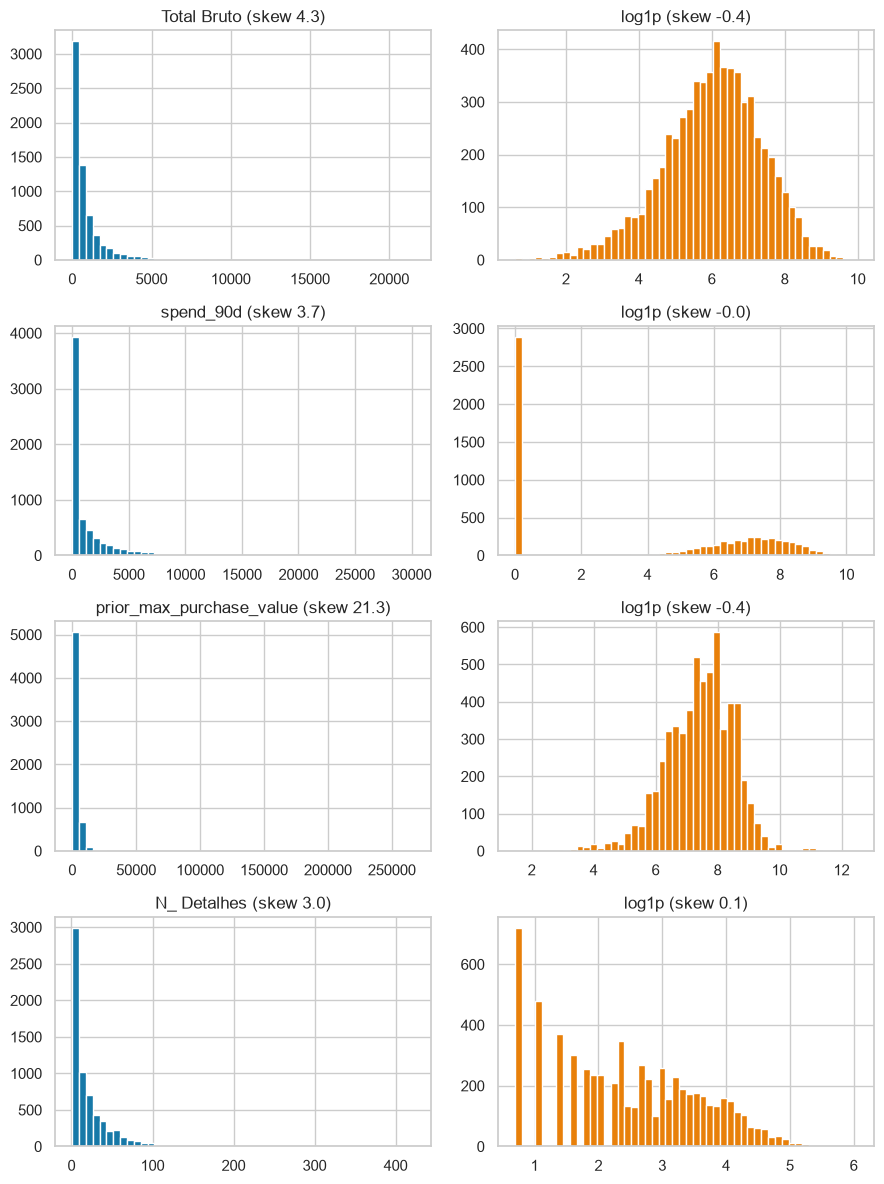

In [22]:
nonneg_cols = [c for c in numeric if c != "random_noise"]
skew_table = pd.DataFrame({
    "skew": train_view[nonneg_cols].skew(),
    "skew after log1p": np.log1p(train_view[nonneg_cols]).skew(),
    "% zeros": 100 * (train_view[nonneg_cols] == 0).mean(),
    "% missing": 100 * train_view[nonneg_cols].isna().mean(),
})
skew_table["log helps"] = skew_table["skew after log1p"].abs() < skew_table["skew"].abs()
print(skew_table.sort_values("skew", ascending=False).round(2).to_string())

cols = ["Total Bruto", "spend_90d", "prior_max_purchase_value", "N_ Detalhes"]
fig, axes = plt.subplots(len(cols), 2, figsize=(9, 3 * len(cols)))
for row, column in zip(axes, cols):
    s = train_view[column].dropna()
    row[0].hist(s, bins=50, color=PLOT_BLUE)
    row[0].set_title(f"{column} (skew {s.skew():.1f})")
    row[1].hist(np.log1p(s), bins=50, color=PLOT_ORANGE)
    row[1].set_title(f"log1p (skew {np.log1p(s).skew():.1f})")
plt.tight_layout()
plt.show()

**Resultado.** `log1p` reduz o skew em todas as colunas (`log helps = True`) exceto `customer_tenure_days`, que já era quase simétrica (0,63) e passa a ser assimétrica à esquerda (-1,82), por isso não se transforma. Onde a coluna tem poucos zeros, o log dá simetria: `prior_max_purchase_value` vai de 21,3 para -0,44, `prior_mean_purchase_value` de 21,2 para -0,29, `Total Bruto` de 4,3 para -0,43. Onde há muitos zeros, o skew desce mas continua alto, porque o pico em zero fica: `Total Desc_ Global` (97% de zeros) de 27,5 para 9,3, `Total Portes` (83%) de 19,6 para 2,3, `purchase_count_30d` (66%) de 3,3 para 1,5. `invoice_count_current_purchase` só desce de 6,4 para 5,0: é uma contagem quase constante (1 em quase todas as linhas) com uma cauda curta. Nestas colunas o que importa é o indicador \"teve / não teve\", mais do que a transformação.

### 5.2 Variáveis categóricas

O que importa em cada categórica é quantos níveis tem, se um domina, e quantos são tão raros que nenhum modelo os aprende.

                  levels  % missing                    top level  top share %  levels under 1% of rows
transport_method      80       3.99   Maybe Tomorrow Delivery 72        17.84                       59
payment_type           9       3.98     Maybe Tomorrow Payment 7        72.76                        5
salesperson            9       3.96             VLOOKUP Master 1        64.61                        4
commercial_zone        5       0.99  Decorative Dashboard Zone 4        96.77                        3
document_series        3       0.99              Ctrl Z Series 2        42.32                        0
warehouse              2       3.98      Final Excel Warehouse 1        99.67                        1


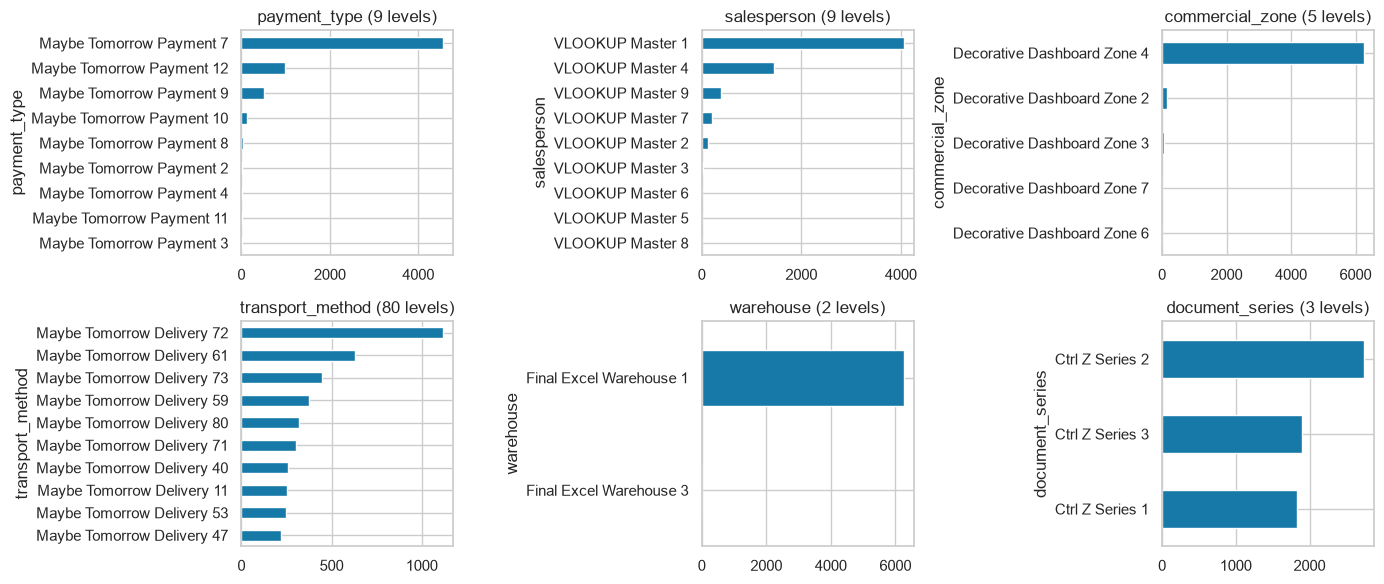

In [23]:
def top_level(s):
    return s.value_counts().index[0]

cat_profile = pd.DataFrame({
    "levels": train_data[categorical_features].nunique(),
    "% missing": 100 * train_data[categorical_features].isna().mean(),
    "top level": train_data[categorical_features].apply(top_level),
    "top share %": 100 * train_data[categorical_features].apply(
        lambda s: s.value_counts(normalize=True).iloc[0]),
    "levels under 1% of rows": train_data[categorical_features].apply(
        lambda s: int((s.value_counts(normalize=True) < 0.01).sum())),
}).sort_values("levels", ascending=False)
print(cat_profile.round(2).to_string())

fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for ax, column in zip(axes.ravel(), categorical_features):
    train_data[column].value_counts().head(10).sort_values().plot(
        kind="barh", color=PLOT_BLUE, ax=ax)
    ax.set_title(f"{column} ({train_data[column].nunique()} levels)")
plt.tight_layout()
plt.show()

**Resultado.** `transport_method` tem 80 níveis, 59 dos quais com menos de 1% das linhas, e o mais comum só cobre 17,8%. `payment_type` (72,8% num nível) e `salesperson` (64,6%) são dominadas por um valor. `commercial_zone` (96,8% na zona 4) e `warehouse` (99,67% no armazém 1) são quase constantes. `document_series` é a única equilibrada (3 níveis, o maior com 42,3%). Em quatro colunas faltam cerca de 4% dos valores e nas outras duas cerca de 1%, o que corresponde às 65 linhas vazias mais os nulos dispersos de 3.1. Consequência: `warehouse` e `commercial_zone` quase não distinguem linhas, e em `transport_method` agrupar os níveis raros em \"Outros\" é uma decisão a tomar no NB02.

# <font color='#E8800A'>6 - Relações com o target</font><a class="anchor" id="relacao"></a>

[Back to TOC](#toc)

Cada análise desta secção responde a uma pergunta diferente: **que variáveis acompanham o alvo** (6.1 a 6.3), e **que variáveis dizem o mesmo umas das outras** (6.4 e 6.5). Todas as numéricas usam a cópia de análise, e as linhas do mesmo cliente não são independentes, pelo que os p-values são optimistas e as magnitudes (correlação, V de Cramér) são mais fiáveis do que eles.

### 6.1 Cada variável numérica contra o alvo

Para cada numérica compara-se a **mediana** das compras que repetem com a das que não repetem, e mede-se a **correlação** com o alvo. A correlação usa `log1p` das colunas não negativas, porque a secção 5.1 mostrou que a maioria é muito assimétrica e uma correlação só se lê bem em colunas aproximadamente simétricas. `random_noise` é o **padrão de comparação**: uma variável que não se distingue dele não acompanha o alvo.

In [ ]:
y = train_data[target]
nonneg_cols = [c for c in numeric if c != "random_noise"]

# A correlation is only readable on roughly symmetric columns, and 5.1 showed that
# log1p makes most of them so. random_noise is left as it is.
log_view = np.log1p(train_view[nonneg_cols]).assign(random_noise=train_view["random_noise"])

signal = pd.DataFrame({
    "median if repeat = 0": train_view.loc[y == 0, numeric].median(),
    "median if repeat = 1": train_view.loc[y == 1, numeric].median(),
    "corr with target (log1p)": log_view[numeric].corrwith(y),
})
signal["|corr|"] = signal["corr with target (log1p)"].abs()
signal = signal.sort_values("|corr|", ascending=False)
noise_corr = signal.loc["random_noise", "|corr|"]
print(signal.round(3).to_string())
print(f"\nrandom_noise |corr|: {noise_corr:.4f}")
print("not above random_noise:", list(signal.index[signal["|corr|"] <= noise_corr]))

fig, ax = plt.subplots(figsize=(8, 7))
signal["|corr|"].sort_values().plot(kind="barh", color=PLOT_BLUE, ax=ax)
ax.axvline(noise_corr, color=PLOT_ORANGE, lw=2, ls="--", label="random_noise")
ax.set(xlabel="|correlation with the target|", title="Each numeric feature against the target")
ax.legend()
plt.tight_layout()
plt.show()

**O que procurar.** As variáveis com |corr| acima da linha laranja acompanham o alvo, e o sinal da correlação diz em que sentido. As medianas por classe mostram a mesma coisa em unidades reais. Uma variável abaixo da linha pode ainda ser útil em combinação com outras, que uma correlação isolada não vê. Uma relação que sobe e desce (não monótona) também dá correlação baixa, e é para isso que serve a análise por intervalos de 6.2.

**[A preencher com o output desta célula depois de a correr.]**

### 6.2 Forma da relação

A correlação resume numa só cifra; a **taxa do alvo por intervalo** mostra a forma. Os intervalos são quantis, e a categoria `missing` mostra se o vazio, só por si, informa.

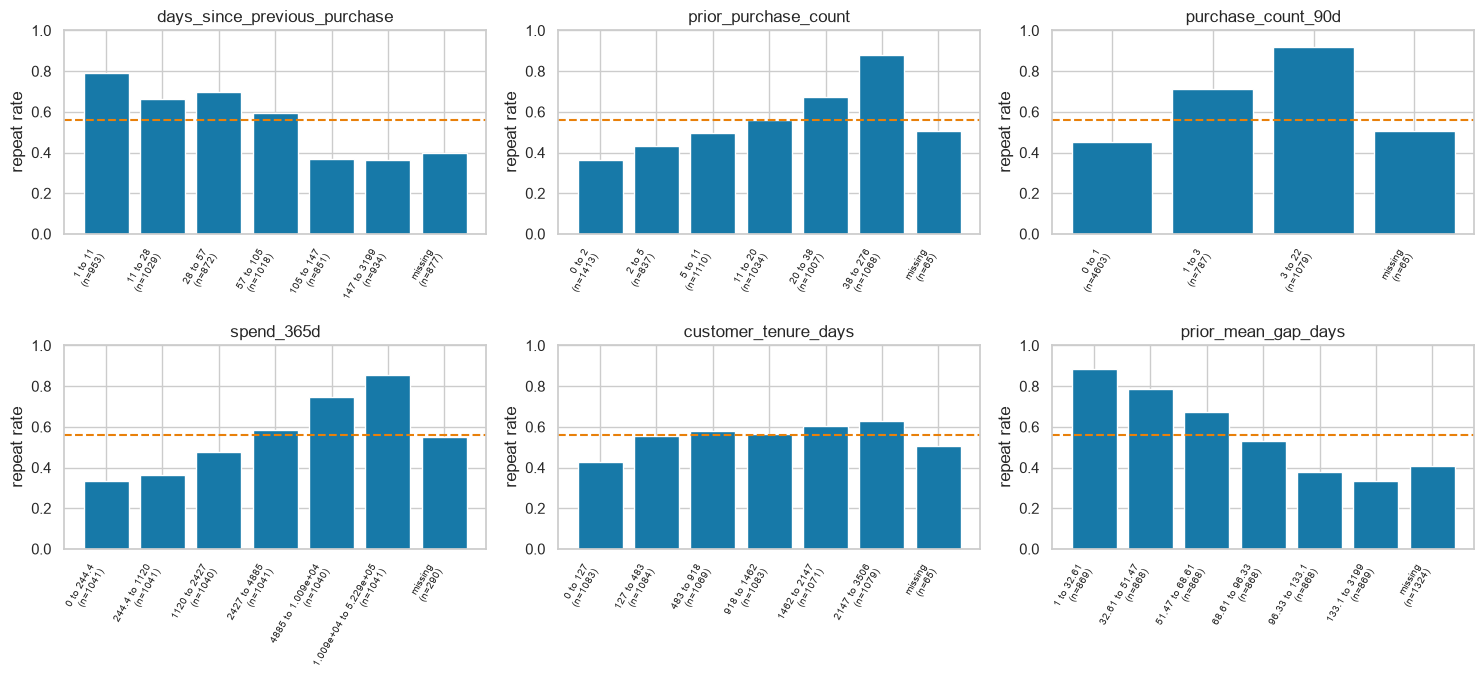

In [25]:
def rate_by_bin(frame, column, y, q=6):
    s = frame[column]
    binned, edges = pd.qcut(s, q=q, labels=False, retbins=True, duplicates="drop")
    labels = {i: f"{edges[i]:.4g} to {edges[i + 1]:.4g}" for i in range(len(edges) - 1)}
    order = [labels[i] for i in range(len(labels))]
    if s.isna().any():
        order.append("missing")
    names = binned.map(labels).fillna("missing")
    out = pd.DataFrame({"bin": names, "y": y}).groupby("bin")["y"].agg(["mean", "size"])
    return out.reindex(order)

key_features = ["days_since_previous_purchase", "prior_purchase_count",
                "purchase_count_90d", "spend_365d",
                "customer_tenure_days", "prior_mean_gap_days"]
base_rate = y.mean()
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, column in zip(axes.ravel(), key_features):
    table = rate_by_bin(train_view, column, y)
    ax.bar(range(len(table)), table["mean"], color=PLOT_BLUE)
    ax.axhline(base_rate, color=PLOT_ORANGE, ls="--", lw=1.5)
    ax.set_xticks(range(len(table)))
    ax.set_xticklabels([f"{b}\n(n={n})" for b, n in zip(table.index, table["size"])],
                       rotation=60, ha="right", fontsize=7)
    ax.set(title=column, ylim=(0, 1), ylabel="repeat rate")
plt.tight_layout()
plt.show()

**Resultado.** A relação com o comportamento do cliente é forte e monótona. A taxa sobe com `prior_purchase_count` (de cerca de 0,36 para 0,88), com `spend_365d` (de 0,33 para 0,85) e com `purchase_count_90d` (de 0,45 com 0 a 1 compras para 0,92 com 3 ou mais). Desce com o tempo entre compras: `days_since_previous_purchase` vai de cerca de 0,79 (1 a 11 dias) para 0,36 (mais de 105 dias), e `prior_mean_gap_days` de 0,88 para 0,33. Quem compra com frequência, recentemente e com muito gasto acumulado é quem volta. `customer_tenure_days` é quase plana (0,55 a 0,63) exceto nos clientes com menos de 127 dias (0,43): a antiguidade conta pouco. A escada é monótona, por isso uma transformação monótona como o log chega. A barra `missing` fica abaixo da taxa global (0,40 em `days_since_previous_purchase`, 0,41 em `prior_mean_gap_days`), o que diz que o vazio **é informação**: clientes sem histórico anterior tendem a não voltar, e um indicador de em falta tem valor.

### 6.3 Variáveis categóricas

Para cada categórica mede-se a força da associação com o alvo (V de Cramér, comparável entre colunas) e vê-se o nível que mais se afasta da taxa global. Com `Bonferroni` porque são vários testes em simultâneo.

In [26]:
rows = []
for column in categorical_features:
    table = pd.crosstab(train_data[column], train_data[target])
    chi2, p, _, expected = chi2_contingency(table)
    rows.append({"feature": column, "levels": table.shape[0],
                 "Cramer's V": association(table, method="cramer", correction=True),
                 "p": p, "min expected count": expected.min()})
cat_target = pd.DataFrame(rows).set_index("feature").sort_values("Cramer's V", ascending=False)
cat_target["reliable"] = cat_target["min expected count"] >= 5
cat_target["significant (Bonferroni)"] = cat_target["p"] < 0.05 / len(cat_target)
print(cat_target.round(4).to_string())

for column in [c for c in categorical_features if train_data[c].nunique() <= 6]:
    print(f"\n{column}")
    print(train_data.groupby(column)[target].agg(rate="mean", rows="size").round(3).to_string())

wide = [c for c in categorical_features if train_data[c].nunique() > 6]
for column in wide:
    by_level = train_data.groupby(column)[target].agg(rate="mean", rows="size")
    by_level = by_level[by_level["rows"] >= 50].sort_values("rate")
    print(f"\n{column}: lowest and highest rate among levels with 50+ rows")
    print(pd.concat([by_level.head(3), by_level.tail(3)]).round(3).to_string())

                  levels  Cramer's V       p  min expected count  reliable  significant (Bonferroni)
feature                                                                                             
transport_method      80      0.2899  0.0000              0.4400     False                      True
payment_type           9      0.2376  0.0000              1.7616     False                      True
salesperson            9      0.2033  0.0000              1.3243     False                      True
commercial_zone        5      0.0638  0.0000              0.4403     False                      True
warehouse              2      0.0266  0.0348              9.2950      True                     False
document_series        3      0.0029  0.9727            804.7834      True                     False

commercial_zone
                              rate  rows
commercial_zone                         
Decorative Dashboard Zone 2  0.411   151
Decorative Dashboard Zone 3  0.357    56
Decorative 

**Resultado.** `transport_method` (V = 0,29), `payment_type` (0,24), `salesperson` (0,20) e `commercial_zone` (0,06) são significativas depois de Bonferroni, mas **nenhuma é fiável**: o mínimo esperado é inferior a 5 em todas. As duas fiáveis não têm associação relevante: `document_series` (0,003, com taxas de 0,561, 0,558 e 0,561 nas três séries) e `warehouse` (0,027, e o armazém 3 só tem 21 linhas). Alguns níveis têm taxas extremas, como `payment_type` 9 (0,95, 502 linhas), `transport_method` 11 (0,98, 253 linhas) e 22 (0,86, 50 linhas), contra `transport_method` 68 (0,26, 163 linhas). Com 610 clientes e muitas linhas por cliente, é provável que cada um destes níveis seja de poucos clientes, e o que se vê é o comportamento desses clientes e não uma propriedade da forma de pagamento ou do transporte. Esta hipótese fica por verificar contando clientes por nível.

### 6.4 Colinearidade entre numéricas

Correlação entre todas as numéricas, calculada sobre `log1p` (pelo mesmo motivo de 6.1). As colunas aparecem pela ordem do dicionário de dados, que já as agrupa por bloco: monetárias, histórico e janelas rolling.

In [ ]:
corr = log_view[numeric].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, vmin=-1, vmax=1, cmap="vlag", square=True,
            cbar_kws={"label": "correlation"}, ax=ax)
ax.set_title("Numeric features (log1p), in the order of the data dictionary")
plt.tight_layout()
plt.show()

pairs = (corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
         .stack().rename("corr").reset_index())
pairs.columns = ["a", "b", "corr"]
strong = pairs[pairs["corr"].abs() >= 0.9].sort_values("corr", key=abs, ascending=False)
print(f"{len(strong)} pairs with |corr| >= 0.9")
print(strong.round(3).to_string(index=False))
print(f"\nlargest |corr| involving random_noise: {corr['random_noise'].drop('random_noise').abs().max():.3f}")

**O que procurar.** Os blocos esperados são o monetário da compra atual, as janelas rolling encaixadas e as estatísticas `prior_*`. Colunas com |corr| ≥ 0,9 trazem quase a mesma informação: num modelo linear desestabilizam os coeficientes, e em modelos de árvore dividem a importância. O NB02 decide se mantém uma por bloco ou as combina em rácios. A correlação máxima de `random_noise` com as outras é o piso do que se pode chamar \"ruído\".

**[A preencher com o output desta célula depois de a correr.]**

### 6.5 Associação entre categóricas

Duas categóricas fortemente associadas dizem a mesma coisa (por exemplo, um armazém que só usa uma série documental).

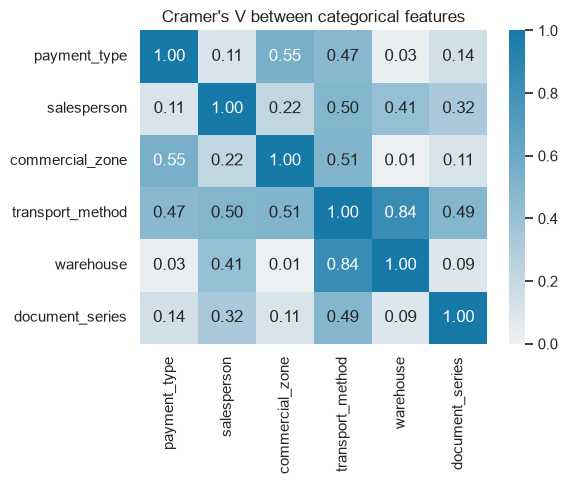

In [28]:
cats = categorical_features
cramer = pd.DataFrame(1.0, index=cats, columns=cats)
for a in cats:
    for b in cats:
        if a != b:
            cramer.loc[a, b] = association(pd.crosstab(train_data[a], train_data[b]),
                                           method="cramer", correction=True)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cramer, vmin=0, vmax=1, annot=True, fmt=".2f",
            cmap=sns.light_palette(PLOT_BLUE, as_cmap=True), ax=ax)
ax.set_title("Cramer's V between categorical features")
plt.tight_layout()
plt.show()

**Resultado.** `transport_method` associa-se a todas as outras: `warehouse` (V = 0,84), `commercial_zone` (0,51), `salesperson` (0,50), `document_series` (0,49) e `payment_type` (0,47). Também há ligação entre `payment_type` e `commercial_zone` (0,55) e entre `salesperson` e `warehouse` (0,41). Por outro lado, `salesperson` e `commercial_zone` quase não se ligam (0,22), ao contrário do que se podia esperar. Cuidado com a leitura: `transport_method` tem 80 níveis e `warehouse` quase só um, e com tabelas assim esparsas o V sobe por construção, por isso estes valores são um indício de redundância e não uma medida exata. Não há razão para manter as seis colunas como se fossem independentes.

# <font color='#E8800A'>7 - Estrutura temporal, repetição de clientes e deriva train vs. test</font><a class="anchor" id="temporal"></a>

[Back to TOC](#toc)

### 7.1 A data

`purchase_date` está guardada como texto. Converte-se numa **série local** (as colunas originais não são alteradas) para ver o intervalo coberto, e quanto do teste cai depois do fim do treino, que é o que distingue um corte temporal de uma partição aleatória.

In [29]:
train_date = pd.to_datetime(train_data[date_col], errors="coerce")
test_date = pd.to_datetime(test_data[date_col], errors="coerce")
print(f"unparsable dates: train {train_date.isna().sum()}, test {test_date.isna().sum()}")
print(f"train: {train_date.min():%Y-%m-%d} to {train_date.max():%Y-%m-%d}"
      f" ({train_date.nunique()} distinct dates)")
print(f"test:  {test_date.min():%Y-%m-%d} to {test_date.max():%Y-%m-%d}"
      f" ({test_date.nunique()} distinct dates)")
print(f"share of test rows dated after the last train date: {(test_date > train_date.max()).mean():.2%}")

seen_rows = test_data["customer_id"].isin(train_data["customer_id"]).mean()
seen_customers = (test_data["customer_id"].drop_duplicates()
                  .isin(train_data["customer_id"]).mean())
print(f"test rows whose customer is in train: {seen_rows:.2%}")
print(f"distinct test customers present in train: {seen_customers:.2%}")

unparsable dates: train 65, test 0
train: 2015-07-11 to 2025-02-15 (1492 distinct dates)
test:  2025-05-24 to 2026-10-06 (223 distinct dates)
share of test rows dated after the last train date: 100.00%
test rows whose customer is in train: 94.52%
distinct test customers present in train: 89.32%


**Resultado.** O treino cobre de 2015-07-11 a 2025-02-15 (1492 datas distintas) e o teste de 2025-05-24 a 2026-10-06 (223 datas): **100% do teste é posterior ao treino**, com um intervalo de cerca de 98 dias entre os dois, mais do que a janela do alvo (90 dias). O problema é, por isso, prever o futuro, e a validação deve imitar isso (treino no passado, validação no mais recente, com margem de 90 dias). Há 65 datas por converter no treino (as 65 linhas vazias) e nenhuma no teste. Quanto aos clientes, 94,52% das linhas do teste e 89,32% dos clientes distintos do teste existem no treino, ou seja, cerca de 11% dos clientes do teste são **novos**, sem histórico, o que confirma o pressuposto da secção 3, mas com esta ressalva.

### 7.2 Volume e taxa do alvo ao longo do tempo

A linha a tracejado marca os últimos 90 dias do treino. O alvo olha 90 dias para a frente, por isso as compras aí têm a janela incompleta, e se a taxa cai nessa zona é um artefacto da observação, não um comportamento.

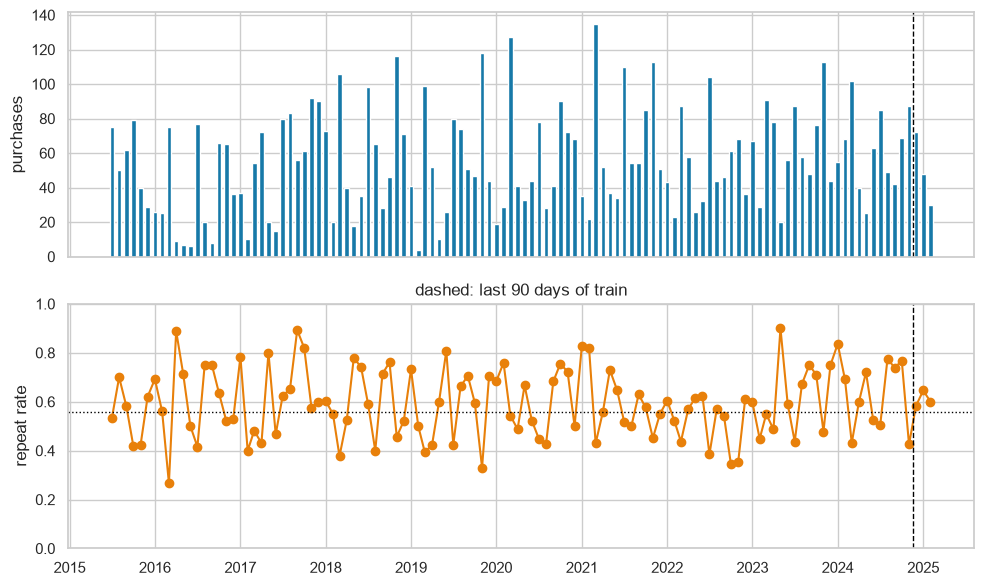

In [30]:
month = train_date.dt.to_period("M")
monthly = pd.DataFrame({"rows": month.value_counts().sort_index(),
                        "target rate": train_data[target].groupby(month).mean()})
x = monthly.index.to_timestamp()
cutoff = train_date.max() - pd.Timedelta(days=90)

fig, (top, bottom) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
top.bar(x, monthly["rows"], width=20, color=PLOT_BLUE)
top.set_ylabel("purchases")
bottom.plot(x, monthly["target rate"], marker="o", color=PLOT_ORANGE)
bottom.axhline(train_data[target].mean(), color="black", ls=":", lw=1)
for ax in (top, bottom):
    ax.axvline(cutoff, color="black", ls="--", lw=1)
bottom.set(ylabel="repeat rate", ylim=(0, 1), title="dashed: last 90 days of train")
plt.tight_layout()
plt.show()

**Resultado.** Não há tendência: a taxa mensal oscila entre cerca de 0,3 e 0,9 à volta dos 0,56 durante os dez anos, sem subir nem descer. A oscilação é maior onde há poucos registos (2015 e 2016, com meses de menos de 10 compras), por isso os extremos de 0,27 e 0,9 são ruído de amostra pequena e não comportamento. O volume é irregular, com meses de menos de 10 e outros acima de 100 compras. Não há queda de taxa nos últimos 90 dias do treino (linha tracejada), por isso o alvo não mostra censura visível nessa zona.

### 7.3 O alvo está escrito na sequência das datas?

`repeat_purchase_90d` diz se o cliente volta em 90 dias. Dentro do treino, essa resposta pode ler-se na **compra seguinte do mesmo cliente**: se a data seguinte está a menos de 90 dias, o alvo é 1. Convém verificar duas coisas: se as datas e `days_since_previous_purchase` concordam, e se o alvo se reconstrói só com as datas.

In [31]:
seq = (pd.DataFrame({"customer_id": train_data["customer_id"], "date": train_date,
                     "ID": train_data["ID"],
                     "reported_gap": train_data["days_since_previous_purchase"],
                     target: train_data[target]})
       .sort_values(["customer_id", "date", "ID"]))
by_customer = seq.groupby("customer_id")["date"]
seq["gap_from_dates"] = (seq["date"] - by_customer.shift(1)).dt.days
seq["next_gap"] = (by_customer.shift(-1) - seq["date"]).dt.days

both = seq["gap_from_dates"].notna() & seq["reported_gap"].notna()
difference = (seq.loc[both, "gap_from_dates"] - seq.loc[both, "reported_gap"])
print(f"rows where both gaps exist: {both.sum()}")
print(f"reported gap equals the gap between dates: {(difference == 0).mean():.2%}")
print("most common differences:", difference.value_counts().head(5).to_dict())

window_complete = seq["date"] <= train_date.max() - pd.Timedelta(days=90)
rules = {"next purchase within 90 days": (seq["next_gap"] <= 90),
         "next purchase 1 to 90 days later": (seq["next_gap"] >= 1) & (seq["next_gap"] <= 90)}
rebuilt = pd.DataFrame({
    name: {"all rows": (rule.astype(int) == seq[target]).mean(),
           "rows with a full 90-day window":
               (rule.astype(int)[window_complete] == seq[target][window_complete]).mean()}
    for name, rule in rules.items()}).T
print("\nshare of rows where the date-based rule reproduces the target:")
print(rebuilt.round(4).to_string())

rows where both gaps exist: 5670
reported gap equals the gap between dates: 98.82%
most common differences: {0.0: 5603, 7.0: 3, 1.0: 2, 105.0: 2, 59.0: 2}

share of rows where the date-based rule reproduces the target:
                                  all rows  rows with a full 90-day window
next purchase within 90 days        0.9864                          0.9975
next purchase 1 to 90 days later    0.9864                          0.9975


**Resultado.** As datas e `days_since_previous_purchase` coincidem em 98,82% das 5670 linhas onde ambas existem (diferença 0 em 5603), e as restantes divergem em poucos casos isolados. O alvo reconstrói-se com a regra \"a compra seguinte do mesmo cliente está a 90 dias ou menos\" em **99,75% das linhas com janela completa** e em 98,64% de todas. As duas regras (com e sem compras no mesmo dia) dão o mesmo valor, por isso as compras no mesmo dia não alteram o resultado. Conclusão: o alvo é praticamente **determinístico a partir da sequência de datas** de cada cliente. Consequências: (1) qualquer variável construída a partir da compra seguinte, como o intervalo da linha seguinte, é fuga direta; (2) as taxas históricas do alvo por cliente só se podem usar com linhas anteriores à janela de 90 dias, senão contêm o futuro; (3) a pequena diferença entre 99,75% e 98,64% vem provavelmente das linhas finais do treino, cuja janela de 90 dias está incompleta.

### 7.4 Deriva entre treino e teste

O teste só se usa para **comparar distribuições**, nunca para ajustar nada. Nas numéricas comparam-se as medianas e a fração de vazios. Nas categóricas, os níveis que só existem no teste e as proporções de cada nível nas colunas com poucos níveis.

In [ ]:
drift_cols = [c for c in numeric if c != "random_noise" and c in test_view.columns and test_view[c].notna().any()]
num_drift = pd.DataFrame({
    "median train": train_view[drift_cols].median(),
    "median test": test_view[drift_cols].median(),
    "% missing train": 100 * train_view[drift_cols].isna().mean(),
    "% missing test": 100 * test_view[drift_cols].isna().mean(),
})
num_drift["median test / train"] = num_drift["median test"] / num_drift["median train"].replace(0, np.nan)
num_drift["distance from 1"] = (num_drift["median test / train"] - 1).abs()
print(num_drift.sort_values("distance from 1", ascending=False).round(3).to_string())

unseen = pd.DataFrame({
    column: {"levels only in test": len(set(test_data[column].dropna()) - set(train_data[column].dropna())),
             "% test rows in unseen levels": 100 * (test_data[column].notna()
                 & ~test_data[column].isin(train_data[column].dropna())).mean()}
    for column in categorical_features}).T
print()
print(unseen.round(2).to_string())

for column in [c for c in categorical_features if train_data[c].nunique() <= 9]:
    shares = pd.DataFrame({"train %": 100 * train_data[column].value_counts(normalize=True),
                           "test %": 100 * test_data[column].value_counts(normalize=True)}).fillna(0)
    print(f"\n{column}")
    print(shares.round(1).to_string())

**O que já se vê.** (1) O teste tem **muito menos vazios** do que o treino: as colunas de totais passam de 0,99% para 0%, `days_since_previous_purchase` de 13,4% para 5,5%, e as `prior_*` de 10 a 23% para 2 a 8%. Isto é coerente com o teste não ter as 65 linhas vazias nem os nulos dispersos de 3.1, e com ter menos clientes sem histórico. (2) Há **níveis só presentes no teste**: `commercial_zone` tem 2, que cobrem 21,2% das linhas do teste, `transport_method` tem 2 (6,4%), `payment_type` 3 (0,3%) e `warehouse` 1 (0,7%). Um modelo nunca viu estes níveis, e o NB02 tem de os agrupar ou tratar à parte. (3) Os valores 1e9 também existem no teste (2 em cada coluna), por isso a regra de limpeza se aplica aos dois ficheiros.

**[A preencher com o output desta célula depois de a correr.]**

# <font color='#E8800A'>8 - Análise crítica de identificadores e ruído</font><a class="anchor" id="analise"></a>

[Back to TOC](#toc)

Um identificador não devia dizer nada sobre o alvo, e `random_noise` também não. Se algum dos dois dissesse, o desenho do ficheiro tem um problema (ou uma fuga), e é melhor descobri-lo agora.

**Identificadores.** Procura-se informação escondida na própria ordem: se o `ID` cresce com a data, ou se acompanha o alvo.

In [ ]:
id_date = pd.DataFrame({"ID": train_data["ID"], "date": train_date}).dropna()
print("ID unique:", train_data["ID"].is_unique,
      "| monotonic increasing:", train_data["ID"].is_monotonic_increasing)
print(f"ID range train {train_data['ID'].min()}-{train_data['ID'].max()},"
      f" test {test_data['ID'].min()}-{test_data['ID'].max()}")
inside = test_data["ID"].between(train_data["ID"].min(), train_data["ID"].max()).mean()
print(f"test ids inside the train id range: {inside:.2%}")
print(f"correlation between ID and date: {id_date['ID'].corr(id_date['date'].map(pd.Timestamp.toordinal)):.3f}")

candidates = pd.DataFrame({"ID": train_data["ID"], "customer_id": train_data["customer_id"],
                           "random_noise": train_view["random_noise"]})
print("\ncorrelation with the target:")
print(candidates.corrwith(y).round(4).to_string())

**O que já se vê.** O `ID` é único e cresce ao longo do ficheiro de treino, mas os ids de treino e de teste estão **misturados** (treino de 10000000 a 10007674, teste de 10000006 a 10007675), e não acompanham a data: o teste é todo posterior ao treino e ainda assim os seus ids estão dentro do mesmo intervalo. O `ID` não é, portanto, um relógio, e não há sobreposição de ids entre os dois ficheiros (secção 2). Para `customer_id`, mesmo uma correlação fraca com o alvo não resolve o problema de fundo (o modelo decorar clientes), tratado nas secções 4 e 7.

**[A preencher com o output desta célula depois de a correr.]**

**Ruído.** `random_noise` deve ser independente de tudo. Verifica-se que tem média perto de 0 e desvio perto de 1, que não se relaciona com o alvo nem com as outras colunas, e que é igual no treino e no teste.

In [ ]:
noise = train_view["random_noise"].dropna()
print(f"mean {noise.mean():.3f}, std {noise.std():.3f}, skew {noise.skew():.3f}")
print(f"correlation with the target: {signal.loc['random_noise', 'corr with target (log1p)']:.4f}")
print(f"largest |correlation| with any other numeric column: {corr['random_noise'].drop('random_noise').abs().max():.3f}")
print(f"median train / test: {train_view['random_noise'].median():.3f} / {test_view['random_noise'].median():.3f}")

above = signal.drop("random_noise")
print(f"\nreal numeric features with more correlation than random_noise: "
      f"{int((above['|corr|'] > noise_corr).sum())} of {len(above)}")

**O que já se vê.** Média de -0,022, desvio de 1,001 e skew de 0,054: `random_noise` comporta-se como uma normal padrão. As correlações com o alvo, com as outras colunas e a comparação treino-teste dependem desta célula.

**[A preencher com o output desta célula depois de a correr.]**

# <font color='#E8800A'>9 - Ligação com o clientes.csv</font><a class="anchor" id="clientes"></a>

[Back to TOC](#toc)

O `clientes.csv` só interessa se (a) cobre os clientes do treino e do teste, (b) a chave é única, para a ligação não duplicar linhas, e (c) as colunas que traz **não contêm o futuro**. Um atributo calculado com todo o período (por exemplo, um total de compras) incluiria compras posteriores à linha, e seria fuga. Esta secção inspeciona o ficheiro e testa essas três coisas **sem alterar** nenhum dos dois.

### 9.1 Estrutura

In [35]:
key = "customer_id"
assert key in clientes_data.columns, f"'{key}' not in clientes.csv: {list(clientes_data.columns)}"

print(clientes_data.shape)
print(clientes_data.head(3).to_string())
print()
print(clientes_data.dtypes.to_string())
null_counts = clientes_data.isna().sum()
print("\nnulls:", null_counts[null_counts > 0].to_dict() or "none")
print(f"key unique: {clientes_data[key].is_unique} | null keys: {clientes_data[key].isna().sum()}"
      f" | duplicated rows: {clientes_data.duplicated().sum()}")

(1143, 13)
   customer_id                        country_or_region               commercial_region                             island                                     municipality                           city                             postal_area                              postal_code                             street                              address  customer_type                      company_name  customer_since_year
0       842570  Country CT11: Land of The Final Version  Region RG37: We Will See Later                                NaN                                              NaN  City CY417: Missing Cell Port                                     NaN  Postal code PC828: #REF! Delivery Route                                NaN  Address AD1120: Cell Without a Home            NaN   Excel Is Not A Database Ltd 150                 2018
1       770941   Country CT9: Land of The Final Version                             NaN                                NaN               

### 9.2 Cobertura e efeito da ligação

In [36]:
cl_keys = set(clientes_data[key].dropna())
coverage = pd.Series({
    "train customers found in clientes": np.mean([k in cl_keys for k in train_data[key].drop_duplicates()]),
    "train rows with a match": train_data[key].isin(cl_keys).mean(),
    "test rows with a match": test_data[key].isin(cl_keys).mean(),
    "clientes rows never seen in train or test":
        1 - np.mean([k in set(train_data[key]) | set(test_data[key]) for k in clientes_data[key].dropna()]),
}).round(4)
print(coverage.to_string())

try:
    train_merged = train_data.merge(clientes_data, on=key, how="left", validate="m:1",
                                    suffixes=("", "_cli"))
    print(f"\nmerge keeps the row count: {len(train_merged) == len(train_data)}"
          f" ({len(train_data)} -> {len(train_merged)})")
except Exception as error:
    train_merged = None
    print("\nmerge failed:", error)

if train_merged is not None:
    matched = train_data[key].isin(cl_keys)
    print(f"repeat rate with a match / without: "
          f"{train_data.loc[matched, target].mean():.3f} / "
          f"{train_data.loc[~matched, target].mean() if (~matched).any() else float('nan'):.3f}")

train customers found in clientes            1.0000
train rows with a match                      1.0000
test rows with a match                       1.0000
clientes rows never seen in train or test    0.4471

merge keeps the row count: True (6534 -> 6534)
repeat rate with a match / without: 0.559 / nan


**Resultado.** A ligação é segura: a chave `customer_id` é única no `clientes.csv`, 100% dos clientes do treino e 100% das linhas do teste têm correspondência, e o `merge` mantém as 6534 linhas. O ficheiro tem 1143 clientes, mas 44,71% deles não aparecem em nenhuma compra do treino ou do teste, e esses não trazem informação para o modelo. Como todas as linhas têm correspondência, não há nada a decidir sobre clientes sem ficha.

### 9.3 O que as colunas do clientes.csv trazem

Cada coluna é classificada (numérica, data ou categórica) e medida contra o alvo, como na secção 6. Para as categóricas compara-se ainda o número de níveis com o número de clientes: uma coluna com quase um nível por cliente identifica o cliente em vez de o descrever. Para as numéricas faz-se um último teste contra **agregados do próprio treino por cliente**: se uma coluna acompanha quase perfeitamente o número de compras ou o gasto do cliente no treino, é um agregado de ciclo de vida e não uma característica estática.

In [ ]:
cli_cols = [c for c in clientes_data.columns if c != key]
empty_cols = [c for c in cli_cols if clientes_data[c].isna().all()]
print("columns of clientes with no values at all:", empty_cols or "none")
cli_cols = [c for c in cli_cols if c not in empty_cols]

cli_numeric = [c for c in cli_cols if pd.api.types.is_numeric_dtype(clientes_data[c])]
cli_dates = []
for column in cli_cols:
    if column in cli_numeric:
        continue
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        parsed = pd.to_datetime(clientes_data[column], errors="coerce")
    if parsed.notna().sum() >= 0.9 * clientes_data[column].notna().sum():
        cli_dates.append(column)
cli_categorical = [c for c in cli_cols if c not in cli_numeric + cli_dates]
print("numeric:", cli_numeric, "\ndates:", cli_dates, "\ncategorical:", cli_categorical)

if train_merged is not None:
    name_of = lambda column: column if column in train_merged else column + "_cli"

    if cli_numeric:
        print("\ncorrelation of the numeric columns of clientes with the target:")
        print(pd.Series({c: train_merged[name_of(c)].corr(y) for c in cli_numeric}).round(4).to_string())

    rows = []
    for column in cli_categorical:
        table = pd.crosstab(train_merged[name_of(column)], train_merged[target])
        if table.shape[0] < 2:
            continue
        chi2, p, _, expected = chi2_contingency(table)
        rows.append({"column": column, "levels": table.shape[0],
                     "levels / customers": table.shape[0] / train_data[key].nunique(),
                     "Cramer's V": association(table, method="cramer", correction=True),
                     "min expected count": expected.min()})
    if rows:
        cli_cat = pd.DataFrame(rows).set_index("column").sort_values("Cramer's V", ascending=False)
        cli_cat["reliable"] = cli_cat["min expected count"] >= 5
        print("\ncategorical columns of clientes against the target:")
        print(cli_cat.round(4).to_string())

    per_customer = train_data.groupby(key).agg(
        n_rows=("ID", "size"), max_prior_count=("prior_purchase_count", "max"),
        max_prior_spend=("prior_total_spend", "max"), repeat_rate=(target, "mean"))
    if cli_numeric:
        joined = per_customer.join(clientes_data.set_index(key)[cli_numeric], how="inner")
        print("\ncorrelation between numeric clientes columns and per-customer aggregates from train:")
        print(joined.corr().loc[cli_numeric, list(per_customer.columns)].round(3).to_string())

    for column in cli_dates:
        later = (pd.to_datetime(train_merged[name_of(column)], errors="coerce") > train_date).mean()
        print(f"\n{column}: dated later than the purchase on {later:.1%} of train rows")

**O que já se vê.** (1) `customer_type` está **vazia nos 1143 clientes**, por isso não serve. (2) `customer_since_year` é a única numérica que sobra: é um ano de registo, estático por natureza, e a sua correlação com o alvo e com os agregados do treino está na célula acima. (3) As colunas de morada têm V de Cramér muito alto (0,59 em `company_name` e `address`, 0,57 em `postal_code` e `street`, 0,53 em `city`), mas **nenhuma é fiável** (mínimo esperado 0,4), e `company_name` tem 609 níveis para 610 clientes do treino: é praticamente um nível por cliente, ou seja, identifica o cliente. O V só é alto porque cada nível é um ou dois clientes, e não generaliza para clientes novos. (4) As colunas mais gerais (`country_or_region` com 7 níveis, `commercial_region` com 32 e `island` com 10) são as únicas com cardinalidade utilizável, mas são as de menor V (0,07, 0,26 e 0,11), e `island`, `city` e `street` têm cerca de metade dos valores em falta. Conclusão: a ficha de cliente traz pouco além do que o histórico de compras já diz.

**[A preencher com o output desta célula depois de a correr.]**

# <font color='#E8800A'>10 - Conclusões e lista de decisões para o notebook 02</font><a class="anchor" id="conclusao"></a>

[Back to TOC](#toc)

**O que este notebook estabeleceu.**

1. **O ficheiro é um histórico de compras, não uma amostra de clientes independentes.** As 6534 linhas pertencem a 610 clientes (453 com várias compras, alguns com 277, 203 e 112), e 94,5% das linhas do teste são de clientes do treino (cerca de 11% dos clientes do teste são novos). O teste é todo posterior ao treino, com um intervalo de cerca de 98 dias, e o alvo olha 90 dias para a frente, o que faz do tempo e do cliente os dois eixos que decidem como se valida (secções 3, 4 e 7).
2. **Os dados em bruto têm defeitos de natureza diferente, e não se tratam todos da mesma forma.** Há valores sentinela (1e9) e negativos que são valores corrompidos mas recuperáveis a partir de outras colunas, intervalos negativos com um código repetido (-4), 65 linhas praticamente vazias, vazios estruturais (clientes sem histórico) e vazios dispersos que a estrutura não explica (secções 3.1 a 3.3).
3. **A forma das distribuições decide a transformação.** A grande maioria das numéricas é assimétrica à direita, e a secção 5.1 mede onde `log1p` resolve e onde só o pico em zero domina.
4. **O sinal está no comportamento passado do cliente.** A taxa de repetição sobe de forma monótona com o número de compras e o gasto anteriores e desce com o tempo entre compras, enquanto as colunas da compra atual quase não acompanham o alvo (secção 6). As colunas dentro de cada bloco são redundantes entre si, e `random_noise` serve de piso para o que se pode chamar sinal (secções 6.1, 6.4 e 8).
5. **O alvo está escrito na sequência das datas.** Isso torna perigosa qualquer variável construída a partir da compra seguinte, e qualquer taxa histórica do alvo que inclua a janela de 90 dias (secção 7.3).

**Lista de problemas detetados.**

| # | achado | evidência |
|---|---|---|
| 1 | `purchase_date` está em texto, com 1492 níveis distintos, e 65 valores não se convertem | secção 2, 7.1 |
| 2 | `customer_id` é chave de agrupamento: 610 clientes, 453 com várias compras, e taxa de repetição de 55,92% por linha contra 26,84% por cliente | secção 3, 4 |
| 3 | valores sentinela 1e9: 16 em `prior_mean_purchase_value` e 15 em `spend_365d` no treino, e 2 de cada no teste | secção 3.2 |
| 4 | valores negativos corrompidos: 16 em `prior_mean_purchase_value` e 15 em `spend_365d`, recuperáveis (a média reconstruída é positiva em 100% dos casos). Intervalos de -4 dias, sempre o mesmo valor, em 16 linhas de `days_since_previous_purchase` e `prior_mean_gap_days` | secção 3.2 |
| 5 | 65 linhas praticamente vazias (36 nulos em 39 colunas), só no treino, e 39,87% das linhas com algum nulo | secção 3.1, 7.4 |
| 6 | vazios estruturais nas colunas `prior_*` (603 a 1413 por coluna), explicados pelo histórico, e a regra nunca falha | secção 3.1 |
| 7 | cerca de 195 vazios não explicados em oito colunas: `transport_method`, `warehouse`, `payment_type`, `salesperson`, `spend_365d`, `days_since_previous_purchase`, `prior_mean_purchase_value` e `prior_mean_gap_days` | secção 3.1 |
| 8 | incoerências: `Total a Pagar` difere da soma dos componentes em 12,01%, `prior_total_spend < spend_365d` em 3,57%, `prior_min <= prior_mean <= prior_max` violada em 3,88% e `Custo > Total Liquido` em 0,60% | secção 3.3 |
| 9 | assimetria forte (skew > 3 em 25 das 29 numéricas). `log1p` dá simetria onde há poucos zeros e não resolve onde há muitos. `customer_tenure_days` é a exceção | secção 5.1 |
| 10 | colunas quase constantes: `Total Desc_ Global` (97% de zeros), `Total Portes` (83%), `warehouse` (99,67% num nível) e `commercial_zone` (96,77%) | secção 5, 5.2 |
| 11 | `transport_method` tem 80 níveis, 59 abaixo de 1% das linhas, e as categóricas associam-se entre si (`transport_method` com `warehouse`, V = 0,84) | secção 5.2, 6.5 |
| 12 | sinal concentrado no comportamento passado do cliente. A compra atual quase não acompanha o alvo e as categóricas fiáveis (`document_series`, `warehouse`) também não | secção 6.1 a 6.3 |
| 13 | colinearidade dentro dos blocos monetário, rolling e `prior_*` | secção 6.4 |
| 14 | alvo reproduzível a partir das datas: 99,75% nas linhas com janela completa | secção 7.3 |
| 15 | teste todo posterior ao treino, cerca de 11% de clientes novos, `commercial_zone` com níveis só no teste (21,2% das linhas) e muito menos vazios no teste | secção 7.1, 7.4 |
| 16 | `random_noise` é ruído por construção | secção 8 |
| 17 | `clientes.csv`: chave única e cobertura de 100%, `customer_type` 100% vazia e colunas de morada com quase um nível por cliente | secção 9 |